# 18. 수작업 특징으로 12종 생성기 분류

FAKE만 사용해 RBF-SVM이 12개 생성기를 구별하는지 확인한다. 전체 집합과 생성기별 원곡을 맞춘 집합을 따로 평가하며, 한 곡의 Segment 점수는 평균한다.

## 1. 경로 / 데이터

In [1]:

from pathlib import Path
import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
)

PROJECT_ROOT = Path("/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project")
FEATURE_PATH = PROJECT_ROOT / "data/processed/features/handcrafted_features_10s.csv"
SEGMENT_PATH = PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv"
RESULT_DIR = PROJECT_ROOT / "results/generator_attribution/handcrafted"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints/generator_attribution"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

features = pd.read_csv(FEATURE_PATH)
segments = pd.read_csv(SEGMENT_PATH).reset_index(drop=True)

print("Feature rows:", len(features))
print("Segment rows:", len(segments))
# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(features) == 10077
assert len(segments) == 10077
print("Input QC PASS: True")

Feature rows: 10077
Segment rows: 10077
Input QC PASS: True


## 2. Feature QC

In [2]:
# segment_manifest에 존재하는 컬럼은 모두 metadata로 간주해 제외한다.
segment_meta_cols = set(segments.columns)

# handcrafted feature CSV에만 존재하는 관리/상태 컬럼도 명시적으로 제외
extra_meta_cols = {
    "Unnamed: 0",
    "index",
    "cache_index",
    "extraction_success",
    "success",
    "error",  # feature extraction 상태/오류 기록 컬럼 → 실제 음향 feature가 아님
}

feature_cols = [
    c
    for c in features.columns
    if c != "segment_id"
    and c not in segment_meta_cols
    and c not in extra_meta_cols
    and not str(c).startswith("Unnamed:")
    and pd.api.types.is_numeric_dtype(features[c])
]

print("Detected feature columns:", len(feature_cols))

if len(feature_cols) != 266:
    numeric_cols = [
        c
        for c in features.columns
        if c != "segment_id" and pd.api.types.is_numeric_dtype(features[c])
    ]

    excluded_numeric = [c for c in numeric_cols if c not in feature_cols]

    print("\nExcluded numeric metadata/status columns:")
    print(excluded_numeric)

    print("\nFirst 40 detected feature columns:")
    print(feature_cols[:40])

    raise ValueError(
        f"Expected 266 handcrafted features, got {len(feature_cols)}. "
        "위 Excluded/Detected 목록을 보내주세요."
    )

meta = segments[
    [
        "segment_id",
        "track_sample_id",
        "original_audio",
        "label",
        "label_id",
        "generator",
        "genre",
        "split",
    ]
].copy()

data = meta.merge(
    features[["segment_id"] + feature_cols],
    on="segment_id",
    how="inner",
    validate="one_to_one",
)

fake = data[data["label"] == "FAKE"].copy()

print("Merged rows:", len(data))
print("FAKE segments:", len(fake))
print("Generators:", fake["generator"].nunique())
print("NaN:", int(fake[feature_cols].isna().sum().sum()))
print("Inf:", int(np.isinf(fake[feature_cols].to_numpy()).sum()))

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(data) == 10077
assert len(fake) == 9189
assert fake["generator"].nunique() == 12
assert not fake[feature_cols].isna().any().any()
assert not np.isinf(fake[feature_cols].to_numpy()).any()

print("Handcrafted Feature QC PASS: True")

Detected feature columns: 266
Merged rows: 10077
FAKE segments: 9189
Generators: 12
NaN: 0
Inf: 0
Handcrafted Feature QC PASS: True


## 3. Generator / split / leakage QC

In [3]:

generator_order = sorted(fake["generator"].dropna().unique())
print("Generators:", generator_order)

print("\nSegment distribution")
display(pd.crosstab(fake["generator"], fake["split"]))

track_meta = fake[
    ["track_sample_id", "original_audio", "generator", "genre", "split"]
].drop_duplicates("track_sample_id")

print("\nTrack distribution")
display(pd.crosstab(track_meta["generator"], track_meta["split"]))

groups = {
    s: set(fake.loc[fake["split"] == s, "original_audio"])
    for s in ["train", "val", "test"]
}
print("Train∩Val :", len(groups["train"] & groups["val"]))
print("Train∩Test:", len(groups["train"] & groups["test"]))
print("Val∩Test  :", len(groups["val"] & groups["test"]))

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert not (groups["train"] & groups["val"])
assert not (groups["train"] & groups["test"])
assert not (groups["val"] & groups["test"])
print("Generator Split QC PASS: True")

Generators: ['acestep', 'audioldm', 'brev', 'diffrhythm', 'elevenlabs', 'mubert', 'musicgen', 'producer', 'songgen', 'stableaudio', 'suno', 'udio']

Segment distribution


split,test,train,val
generator,,,
acestep,135,618,129
audioldm,135,609,132
brev,144,612,138
diffrhythm,141,621,135
elevenlabs,144,612,144
mubert,72,300,75
musicgen,135,615,129
producer,75,303,72
songgen,90,409,83



Track distribution


split,test,train,val
generator,,,
acestep,45,206,43
audioldm,45,203,44
brev,48,204,46
diffrhythm,47,207,45
elevenlabs,48,204,48
mubert,24,100,25
musicgen,45,205,43
producer,25,102,24
songgen,45,205,42


Train∩Val : 0
Train∩Test: 0
Val∩Test  : 0
Generator Split QC PASS: True


## 4. 평가 함수

In [4]:


def macro_ovr_auc(y, scores, n_classes):
    vals = []
    for cls in range(n_classes):
        yb = (np.asarray(y) == cls).astype(int)
        if yb.min() != yb.max():
            vals.append(roc_auc_score(yb, scores[:, cls]))
    return float(np.mean(vals))


def top3(y, scores):
    idx = np.argsort(scores, axis=1)[:, -3:]
    return float(np.mean([int(a) in b for a, b in zip(y, idx)]))


def metrics(y, scores, n_classes):
    pred = np.argmax(scores, axis=1)
    return {
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro", zero_division=0),
        "top3_accuracy": top3(y, scores),
        "macro_ovr_auc": macro_ovr_auc(y, scores, n_classes),
    }


def aggregate_tracks(meta, scores, class_names):
    temp = (
        meta[["track_sample_id", "original_audio", "generator", "genre", "split"]]
        .reset_index(drop=True)
        .copy()
    )
    score_cols = []
    for j, cls in enumerate(class_names):
        col = f"score__{cls}"
        score_cols.append(col)
        temp[col] = scores[:, j]

    agg = {
        "original_audio": "first",
        "generator": "first",
        "genre": "first",
        "split": "first",
    }
    agg.update({c: "mean" for c in score_cols})
    track = temp.groupby("track_sample_id", as_index=False).agg(agg)
    return track, score_cols


def run_experiment(df, name, encoder):
    # 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
    train = df[df["split"] == "train"].reset_index(drop=True)
    val = df[df["split"] == "val"].reset_index(drop=True)
    test = df[df["split"] == "test"].reset_index(drop=True)

    Xtr = train[feature_cols].to_numpy(np.float32)
    Xv = val[feature_cols].to_numpy(np.float32)
    Xte = test[feature_cols].to_numpy(np.float32)
    # Train에서 정한 생성기 레이블 번호를 다른 분할에도 그대로 적용한다.
    ytr = encoder.transform(train["generator"])
    yv = encoder.transform(val["generator"])
    # Train에서 정한 생성기 레이블 번호를 다른 분할에도 그대로 적용한다.
    yte = encoder.transform(test["generator"])

    # 특징마다 범위가 달라 표준화한다. 평균·표준편차는 Train에서만 구한다.
    scaler = StandardScaler()
    # Train의 평균·표준편차를 구하고 같은 Train 행을 변환한다.
    Xtr = scaler.fit_transform(Xtr)
    Xv = scaler.transform(Xv)
    Xte = scaler.transform(Xte)

    clf = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        # 클래스별 표본 수가 달라 손실에 기여하는 비중을 조정한다.
        class_weight="balanced",
        decision_function_shape="ovr",
        probability=False,
        cache_size=3000,
        random_state=RANDOM_STATE,
    )

    t0 = time.time()
    # 분류 경계는 Train에만 맞추고 Validation/Test는 선택·평가에 남겨둔다.
    clf.fit(Xtr, ytr)
    print(name, "training min:", round((time.time() - t0) / 60, 2))

    # SVM의 decision score는 확률이 아닌 분류 경계까지의 margin이다.
    sv = clf.decision_function(Xv)
    ste = clf.decision_function(Xte)

    val_track, score_cols = aggregate_tracks(val, sv, encoder.classes_)
    test_track, _ = aggregate_tracks(test, ste, encoder.classes_)

    yv_t = encoder.transform(val_track["generator"])
    yte_t = encoder.transform(test_track["generator"])

    out = pd.DataFrame(
        [
            {
                "experiment": name,
                "level": "segment",
                "split": "val",
                **metrics(yv, sv, len(encoder.classes_)),
            },
            {
                "experiment": name,
                "level": "segment",
                "split": "test",
                **metrics(yte, ste, len(encoder.classes_)),
            },
            {
                "experiment": name,
                "level": "track",
                "split": "val",
                **metrics(
                    yv_t, val_track[score_cols].to_numpy(), len(encoder.classes_)
                ),
            },
            {
                "experiment": name,
                "level": "track",
                "split": "test",
                **metrics(
                    yte_t, test_track[score_cols].to_numpy(), len(encoder.classes_)
                ),
            },
        ]
    )

    return {
        "metrics": out,
        "scaler": scaler,
        "model": clf,
        "test_track": test_track,
        "score_cols": score_cols,
        "y_test_track": yte_t,
    }

## 5. Experiment A — Full FAKE 12-way

In [5]:

# 분류 경계는 Train에만 맞추고 Validation/Test는 선택·평가에 남겨둔다.
encoder = LabelEncoder().fit(generator_order)
print("Class mapping:", dict(enumerate(encoder.classes_)))

full = run_experiment(fake, "full", encoder)
display(full["metrics"].round(4))

print("Chance Top-1:", round(1 / 12, 4))

Class mapping: {0: np.str_('acestep'), 1: np.str_('audioldm'), 2: np.str_('brev'), 3: np.str_('diffrhythm'), 4: np.str_('elevenlabs'), 5: np.str_('mubert'), 6: np.str_('musicgen'), 7: np.str_('producer'), 8: np.str_('songgen'), 9: np.str_('stableaudio'), 10: np.str_('suno'), 11: np.str_('udio')}
full training min: 0.02


,experiment,level,split,accuracy,balanced_accuracy,macro_f1,top3_accuracy,macro_ovr_auc
0,full,segment,val,0.7760,0.7761,0.7718,0.9445,0.9576
1,full,segment,test,0.7780,0.7778,0.7748,0.9402,0.9535
2,full,track,val,0.8799,0.8743,0.8735,0.9752,0.9815
3,full,track,test,0.8846,0.8812,0.8840,0.9798,0.9765


Chance Top-1: 0.0833


## 6. Full Test — generator별 성능 / confusion matrix

,generator,precision,recall,f1-score,support
6,musicgen,1.0000,1.0000,1.0000,45.0
0,acestep,1.0000,0.9778,0.9888,45.0
8,songgen,1.0000,0.9778,0.9888,45.0
1,audioldm,0.9778,0.9778,0.9778,45.0
3,diffrhythm,0.9574,0.9574,0.9574,47.0
4,elevenlabs,0.8800,0.9167,0.8980,48.0
5,mubert,0.9524,0.8333,0.8889,24.0
9,stableaudio,0.8571,0.9231,0.8889,26.0
11,udio,0.8776,0.8958,0.8866,48.0
7,producer,0.8261,0.7600,0.7917,25.0


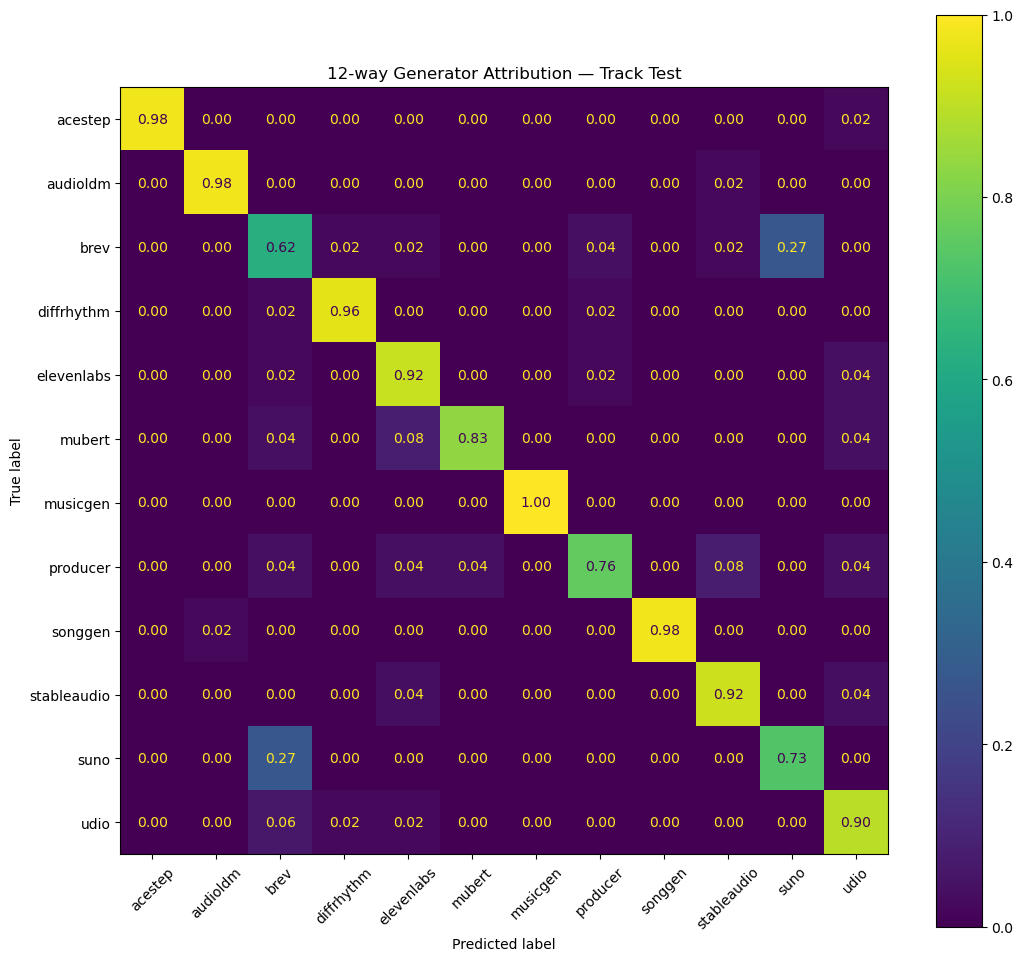

In [6]:

tt = full["test_track"]
scores = tt[full["score_cols"]].to_numpy()
pred_int = np.argmax(scores, axis=1)
pred = encoder.inverse_transform(pred_int)

report = classification_report(
    tt["generator"], pred, labels=encoder.classes_, output_dict=True, zero_division=0
)

per_generator = (
    pd.DataFrame(report)
    .T.loc[encoder.classes_, ["precision", "recall", "f1-score", "support"]]
    .reset_index()
    .rename(columns={"index": "generator"})
)
display(per_generator.sort_values("f1-score", ascending=False).round(4))

cm = confusion_matrix(tt["generator"], pred, labels=encoder.classes_, normalize="true")
fig, ax = plt.subplots(figsize=(11, 10))
ConfusionMatrixDisplay(cm, display_labels=encoder.classes_).plot(
    ax=ax, xticks_rotation=45, values_format=".2f"
)
ax.set_title("12-way Generator Attribution — Track Test")
fig.tight_layout()
fig.savefig(
    RESULT_DIR / "full_track_confusion_matrix.png", dpi=180, bbox_inches="tight"
)
plt.show()

## 7. Controlled 12-generator subset QC

In [7]:
# Controlled 12-generator subset QC

source_n_gen = track_meta.groupby("original_audio")["generator"].nunique()
common_12_sources = set(source_n_gen[source_n_gen == 12].index)

print("Original_audio with all 12 generators:", len(common_12_sources))

controlled = fake[fake["original_audio"].isin(common_12_sources)].copy()
controlled_tracks = controlled[
    ["track_sample_id", "original_audio", "generator", "genre", "split"]
].drop_duplicates("track_sample_id")

print("\nUnique controlled sources by split")
display(
    controlled_tracks.groupby("split")["original_audio"]
    .nunique()
    .to_frame("unique_original_audio")
)

print("\nControlled track distribution")
display(pd.crosstab(controlled_tracks["generator"], controlled_tracks["split"]))

ctab = pd.crosstab(controlled["generator"], controlled["split"])
can_run = (
    len(common_12_sources) > 0
    and set(ctab.index) == set(encoder.classes_)
    and all(s in ctab.columns for s in ["train", "val", "test"])
    and (ctab[["train", "val", "test"]] > 0).all().all()
)

print("Controlled experiment runnable:", can_run)
if not can_run:
    raise RuntimeError("Controlled subset insufficient. 결과를 보내주세요.")

print("Controlled Subset QC PASS: True")

Original_audio with all 12 generators: 119

Unique controlled sources by split


,unique_original_audio
split,
test,19
train,83
val,17



Controlled track distribution


split,test,train,val
generator,,,
acestep,19,83,17
audioldm,19,83,17
brev,38,165,34
diffrhythm,21,85,19
elevenlabs,38,166,34
mubert,19,83,18
musicgen,19,83,17
producer,20,83,17
songgen,19,83,17


Controlled experiment runnable: True
Controlled Subset QC PASS: True


## 8. Experiment B — Controlled subset

In [8]:
# Experiment B — Controlled subset

controlled_res = run_experiment(controlled, "controlled_12", encoder)
display(controlled_res["metrics"].round(4))

controlled_12 training min: 0.01


,experiment,level,split,accuracy,balanced_accuracy,macro_f1,top3_accuracy,macro_ovr_auc
0,controlled_12,segment,val,0.6939,0.7264,0.7275,0.9232,0.9438
1,controlled_12,segment,test,0.6929,0.7334,0.7265,0.9069,0.9329
2,controlled_12,track,val,0.8291,0.8333,0.8395,0.9673,0.9735
3,controlled_12,track,test,0.7720,0.8004,0.8064,0.9642,0.9641


## 9. Full vs Controlled 핵심 비교

In [9]:

all_metrics = pd.concat([full["metrics"], controlled_res["metrics"]], ignore_index=True)

compare = all_metrics[
    # 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
    (all_metrics["level"] == "track") & (all_metrics["split"] == "test")
].copy()

display(
    compare[
        [
            "experiment",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "top3_accuracy",
            "macro_ovr_auc",
        ]
    ].round(4)
)

print("Chance Top-1 accuracy:", round(1 / 12, 4))

,experiment,accuracy,balanced_accuracy,macro_f1,top3_accuracy,macro_ovr_auc
3,full,0.8846,0.8812,0.8840,0.9798,0.9765
7,controlled_12,0.7720,0.8004,0.8064,0.9642,0.9641


Chance Top-1 accuracy: 0.0833


## 10. Genre별 Full Track Test

In [10]:
# Genre별 Full Track Test

rows = []
tt = full["test_track"]
scores = tt[full["score_cols"]].to_numpy()
y = full["y_test_track"]

for genre in sorted(tt["genre"].dropna().unique()):
    mask = tt["genre"].to_numpy() == genre
    yg = y[mask]
    sg = scores[mask]
    predg = np.argmax(sg, axis=1)

    rows.append(
        {
            "genre": genre,
            "n_tracks": int(mask.sum()),
            "accuracy": accuracy_score(yg, predg),
            "balanced_accuracy": balanced_accuracy_score(yg, predg),
            "macro_f1": f1_score(yg, predg, average="macro", zero_division=0),
            "top3_accuracy": top3(yg, sg),
        }
    )

genre_metrics = pd.DataFrame(rows)
display(genre_metrics.round(4))

,genre,n_tracks,accuracy,balanced_accuracy,macro_f1,top3_accuracy
0,Electronic,167,0.8623,0.8360,0.8392,0.9820
1,Pop,131,0.8779,0.8890,0.8860,0.9771
2,Rock,196,0.9082,0.9069,0.9080,0.9796


## 11. 저장 / 최종 QC

In [11]:

all_metrics.to_csv(
    RESULT_DIR / "generator_attribution_metrics.csv", index=False, encoding="utf-8-sig"
)
per_generator.to_csv(
    RESULT_DIR / "full_test_per_generator_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
genre_metrics.to_csv(
    RESULT_DIR / "genre_wise_track_metrics.csv", index=False, encoding="utf-8-sig"
)

joblib.dump(
    {
        "encoder": encoder,
        "feature_cols": feature_cols,
        "scaler": full["scaler"],
        "svm": full["model"],
    },
    CHECKPOINT_DIR / "generator_attribution_rbf_svm_full.joblib",
)
joblib.dump(
    {
        "encoder": encoder,
        "feature_cols": feature_cols,
        "scaler": controlled_res["scaler"],
        "svm": controlled_res["model"],
        "controlled_sources": sorted(common_12_sources),
    },
    CHECKPOINT_DIR / "generator_attribution_rbf_svm_controlled12.joblib",
)

full_test = compare[compare["experiment"] == "full"].iloc[0]
controlled_test = compare[compare["experiment"] == "controlled_12"].iloc[0]

qc = pd.DataFrame(
    {
        "check": [
            "feature_count",
            "fake_segments",
            "generator_count",
            "source_leakage_train_test",
            "full_test_generators",
            "controlled_sources",
            "controlled_test_generators",
            "finite_full_macro_f1",
            "finite_controlled_macro_f1",
        ],
        "value": [
            len(feature_cols),
            len(fake),
            fake["generator"].nunique(),
            len(groups["train"] & groups["test"]),
            len(np.unique(full["y_test_track"])),
            len(common_12_sources),
            len(np.unique(controlled_res["y_test_track"])),
            np.isfinite(full_test["macro_f1"]),
            np.isfinite(controlled_test["macro_f1"]),
        ],
    }
)
display(qc)

core_qc = (
    len(feature_cols) == 266
    and len(fake) == 9189
    and fake["generator"].nunique() == 12
    and len(groups["train"] & groups["test"]) == 0
    and len(np.unique(full["y_test_track"])) == 12
    and len(common_12_sources) > 0
    and len(np.unique(controlled_res["y_test_track"])) == 12
    and np.isfinite(full_test["macro_f1"])
    and np.isfinite(controlled_test["macro_f1"])
)

print("===== FINAL RESULT =====")
print("Generator Attribution Handcrafted Core QC PASS:", core_qc)

,check,value
0,feature_count,266
1,fake_segments,9189
2,generator_count,12
3,source_leakage_train_test,0
4,full_test_generators,12
5,controlled_sources,119
6,controlled_test_generators,12
7,finite_full_macro_f1,True
8,finite_controlled_macro_f1,True


===== FINAL RESULT =====
Generator Attribution Handcrafted Core QC PASS: True


## 수작업 특징 분류 결과

- Handcrafted + RBF-SVM의 Full 12-way Track Test Accuracy는 **0.8846**, Macro-F1은 **0.8840**이다.
- Full Track Top-3 Accuracy는 **0.9798**, Macro OVR AUC는 **0.9765**다.
- Source coverage를 통제한 controlled subset에서도 Track Macro-F1 **0.8064**를 기록했다.
- MusicGen은 가장 뚜렷했고, Brev와 Suno는 상대적으로 혼동이 컸다.
- 결과와 confusion matrix는 `results/generator_attribution/handcrafted/`에 저장했다.